# Banknote Authentication – DBSCAN Clustering
SCT213-C002-0078/2023 - Gaius Peter

**ML II Unsupervised Learning Capstone – Step 3: Modelling**

This notebook applies **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to the preprocessed banknote authentication dataset, building directly on the preprocessing pipeline from Step 2 (Caroline Nyanjui & Catherine Njogu).

---

### Dataset
- **1,372 instances** (1,348 after deduplication)
- **4 features:** `variance`, `skewness`, `curtosis`, `entropy`
- **Target:** `class` (0 = Authentic, 1 = Forged) — used only for evaluation

### Two versions of data used
| Dataset | Features | Notes |
|---|---|---|
| `df_no_pca` | 4 scaled features | Full feature space |
| `df_with_pca` | 2 PCA components | 86.7% variance retained |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    homogeneity_score, completeness_score, v_measure_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
PALETTE = sns.color_palette('tab10', 10)
print('All imports successful.')

All imports successful.


## 2. Load Data & Recreate Preprocessing Pipeline

We replicate the preprocessing from Step 2 exactly:
- Remove duplicates
- Separate target label
- Impute (median) + StandardScale the 4 features
- Apply PCA (2 components)

> **Note:** The `outlier_flag` column from Step 2 is intentionally **excluded** from model input. It is a derived metadata column and including it as a scaled feature would distort Euclidean distances in DBSCAN.

In [2]:
# Load data
DATA_PATH = r"C:\Users\ADMIN\Downloads\data_banknote_authentication.txt"

data = pd.read_csv(DATA_PATH, header=None,
                   names=['variance','skewness','curtosis','entropy','class'])
data = data.drop_duplicates()
print(f'Shape after deduplication: {data.shape}')

# Separate features and labels
y     = data['class'].reset_index(drop=True)
X_raw = data.drop('class', axis=1).reset_index(drop=True)
feature_cols = X_raw.columns.tolist()

# Preprocessing pipeline (mirrors Step 2)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
preprocessor = ColumnTransformer([('num', numeric_pipeline, feature_cols)])
X_scaled = preprocessor.fit_transform(X_raw)

df_no_pca = pd.DataFrame(X_scaled, columns=feature_cols)

# PCA reduction
pca_model = PCA(n_components=2, random_state=42)
X_pca     = pca_model.fit_transform(X_scaled)
df_with_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])

var_retained = pca_model.explained_variance_ratio_.sum()
print(f'PCA variance retained: {var_retained:.1%}')
print(f'\nClass distribution:\n{y.value_counts().rename({0:"Authentic", 1:"Forged"}).to_string()}')
df_no_pca.head()

Shape after deduplication: (1348, 5)
PCA variance retained: 86.7%

Class distribution:
class
Authentic    738
Forged       610


,variance,skewness,curtosis,entropy
0,1.109709,1.151820,-0.975529,0.346132
1,1.432683,1.066810,-0.894937,-0.140707
2,1.195109,-0.775147,0.118015,0.611558
3,1.052054,1.297854,-1.253774,-1.163342
4,-0.040724,-1.084859,0.729928,0.086284


## 3. Choosing `eps` — K-Distance Elbow Plot

DBSCAN requires two hyperparameters:
- **`eps` (ε):** The neighbourhood radius. Points within this distance are considered neighbours.
- **`min_samples`:** Minimum number of points to form a dense core region.

**Rule of thumb:** `min_samples = 2 × n_features`
- No PCA: `min_samples = 2 × 4 = 8` — but we use **15** (more conservative, reduces micro-clusters)
- With PCA: `min_samples = 2 × 2 = 4` — but we use **15** for consistency

**To find `eps`:** Sort k-NN distances in descending order and look for the "elbow" (sharp bend). The distance at the elbow is the optimal `eps`.

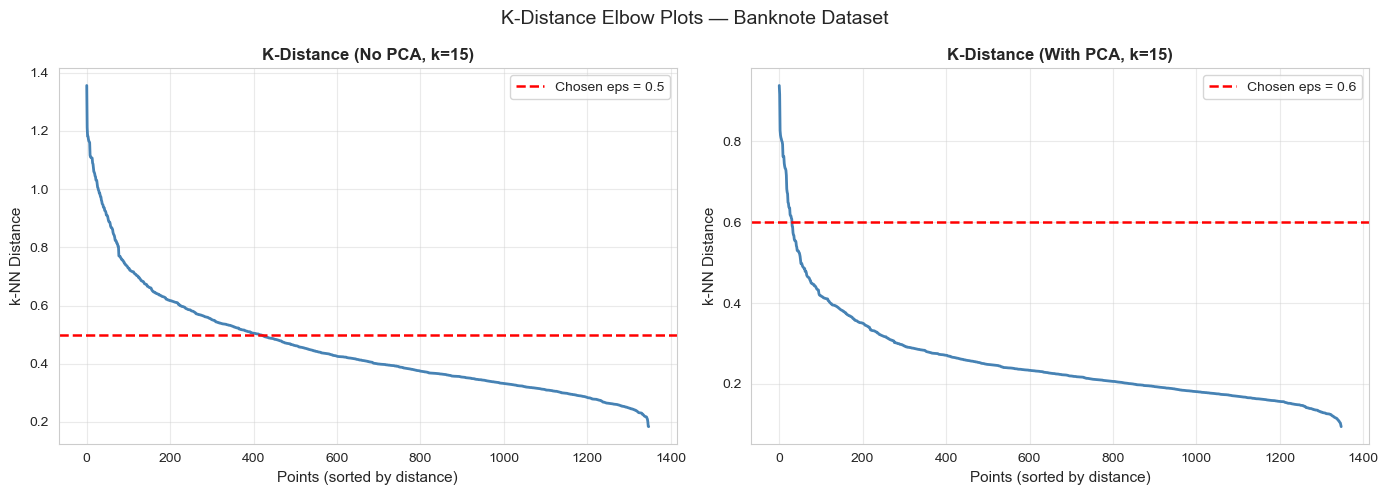

The red dashed line marks the chosen eps at the elbow of each curve.


In [3]:
MIN_SAMPLES = 15  # used for both models

def get_kdist(X, k):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    return np.sort(distances[:, k - 1])[::-1]

kd_full = get_kdist(df_no_pca.values, MIN_SAMPLES)
kd_pca  = get_kdist(df_with_pca.values, MIN_SAMPLES)

EPS_FULL = 0.50  # identified from elbow
EPS_PCA  = 0.60  # identified from elbow

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, kd, eps, title in [
    (axes[0], kd_full, EPS_FULL, f'K-Distance (No PCA, k={MIN_SAMPLES})'),
    (axes[1], kd_pca,  EPS_PCA,  f'K-Distance (With PCA, k={MIN_SAMPLES})')
]:
    ax.plot(kd, color='steelblue', lw=2)
    ax.axhline(eps, color='red', ls='--', lw=1.8, label=f'Chosen eps = {eps}')
    ax.set_xlabel('Points (sorted by distance)', fontsize=11)
    ax.set_ylabel('k-NN Distance', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

plt.suptitle('K-Distance Elbow Plots — Banknote Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('kdistance_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('The red dashed line marks the chosen eps at the elbow of each curve.')

## 4. Fit DBSCAN

| Model | `eps` | `min_samples` | Rationale |
|---|---|---|---|
| No PCA | 0.50 | 15 | Elbow at ~0.5; min_s=15 reduces micro-clusters |
| With PCA | 0.60 | 15 | Wider eps needed in 2D PCA space |

In [6]:
# Fit both models
labels_full = DBSCAN(eps=EPS_FULL, min_samples=MIN_SAMPLES).fit_predict(df_no_pca.values)
labels_pca  = DBSCAN(eps=EPS_PCA,  min_samples=MIN_SAMPLES).fit_predict(df_with_pca.values)

for name, labels in [('No PCA', labels_full), ('With PCA', labels_pca)]:
    n_cls   = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f'[{name}]  Clusters found: {n_cls} | Noise points: {n_noise} ({n_noise/len(labels):.1%})')

[No PCA]  Clusters found: 5 | Noise points: 222 (16.5%)
[With PCA]  Clusters found: 1 | Noise points: 1 (0.1%)


## 5. Visualise Clusters

All clusters are projected into the 2D PCA space for visualisation. The rightmost plot shows the true labels for direct comparison.

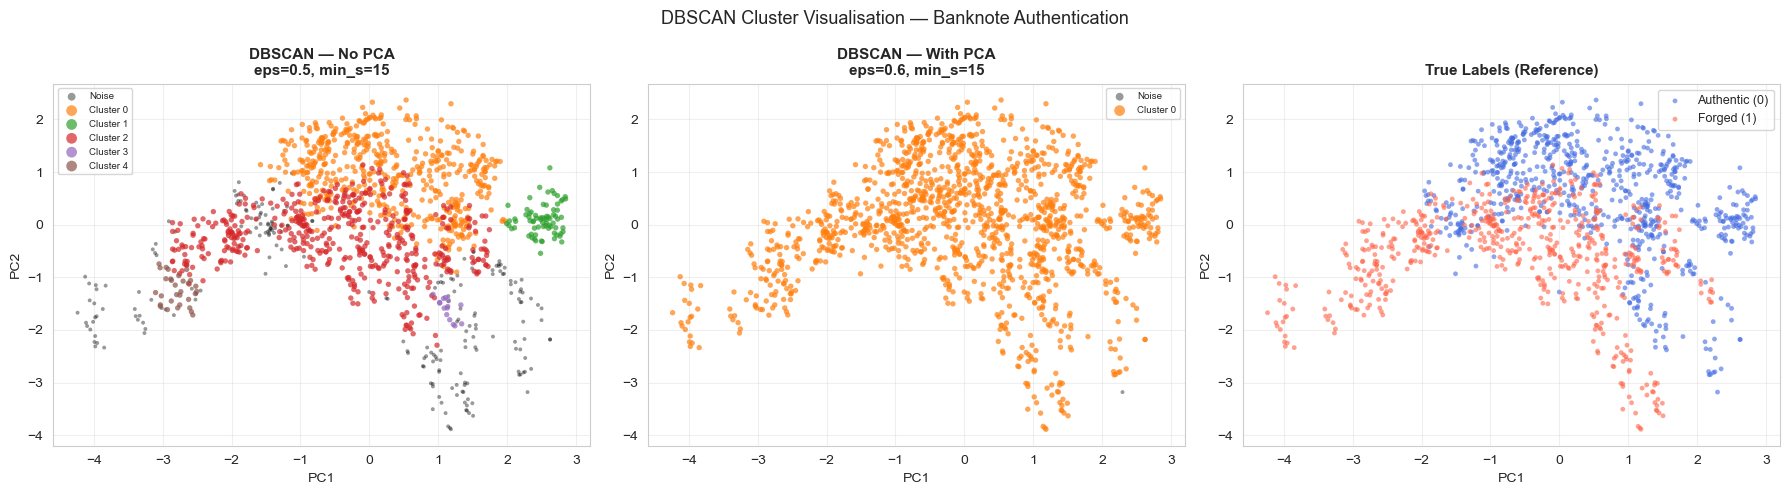

In [9]:
pca_coords = df_with_pca.values

def scatter_clusters(ax, coords, labels, title):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask  = labels == lbl
        color = 'black' if lbl == -1 else PALETTE[i % 10]
        lstr  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(coords[mask, 0], coords[mask, 1], c=[color],
                   s=15 if lbl != -1 else 8,
                   alpha=0.7 if lbl != -1 else 0.4,
                   label=lstr, edgecolors='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_clusters(axes[0], pca_coords, labels_full,
                 f'DBSCAN — No PCA\neps={EPS_FULL}, min_s={MIN_SAMPLES}')
scatter_clusters(axes[1], pca_coords, labels_pca,
                 f'DBSCAN — With PCA\neps={EPS_PCA}, min_s={MIN_SAMPLES}')

# True labels
for cls, color, name in [(0,'royalblue','Authentic (0)'),(1,'tomato','Forged (1)')]:
    mask = y.values == cls
    axes[2].scatter(pca_coords[mask,0], pca_coords[mask,1],
                    c=color, s=12, alpha=0.6, label=name, edgecolors='none')
axes[2].set_title('True Labels (Reference)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('DBSCAN Cluster Visualisation — Banknote Authentication', fontsize=13)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation Metrics

Since we have true labels, we evaluate with both **internal** and **external** metrics.

| Metric | Type | Range | Better |
|---|---|---|---|
| **Silhouette Score** | Internal | −1 to 1 | Higher |
| **Adjusted Rand Index (ARI)** | External | 0 to 1 | Higher |
| **Homogeneity** | External | 0 to 1 | Higher |
| **Completeness** | External | 0 to 1 | Higher |
| **V-Measure** | External | 0 to 1 | Higher |

> Silhouette is computed only on non-noise points (label ≠ −1).

In [10]:
def evaluate_dbscan(X, labels, y_true, name):
    n_cls   = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    mask    = labels != -1
    sil     = round(silhouette_score(X[mask], labels[mask]), 4) \
              if n_cls >= 2 and mask.sum() > 1 else 'N/A'
    return {
        'Model': name,
        'Clusters': n_cls,
        'Noise Points': n_noise,
        'Noise %': f'{n_noise/len(labels):.1%}',
        'Silhouette': sil,
        'ARI': round(adjusted_rand_score(y_true, labels), 4),
        'Homogeneity': round(homogeneity_score(y_true, labels), 4),
        'Completeness': round(completeness_score(y_true, labels), 4),
        'V-Measure': round(v_measure_score(y_true, labels), 4)
    }

r1 = evaluate_dbscan(df_no_pca.values,   labels_full, y.values, f'No PCA  (eps={EPS_FULL})')
r2 = evaluate_dbscan(df_with_pca.values, labels_pca,  y.values, f'With PCA (eps={EPS_PCA})')

eval_df = pd.DataFrame([r1, r2]).set_index('Model')
print('=== DBSCAN Evaluation Summary ===')
display(eval_df)
eval_df.to_csv('dbscan_evaluation.csv')

=== DBSCAN Evaluation Summary ===


,Clusters,Noise Points,Noise %,Silhouette,ARI,Homogeneity,Completeness,V-Measure
Model,,,,,,,,
No PCA (eps=0.5),5,222,16.5%,0.1957,0.5493,0.8105,0.4202,0.5534
With PCA (eps=0.6),1,1,0.1%,N/A,-0.0003,0.0006,0.0735,0.0013


## 7. Cross-Tabulation: DBSCAN Clusters vs True Labels

This tells us how well DBSCAN's clusters align with the authentic/forged classes.

In [13]:
print('=== Cross-Tab: DBSCAN (No PCA) vs True Class ===')
ct = pd.crosstab(labels_full, y.values,
                 rownames=['DBSCAN Cluster'],
                 colnames=['True Class (0=Auth, 1=Forged)'])
display(ct)

print('\n=== Cross-Tab: DBSCAN (With PCA) vs True Class ===')
display(pd.crosstab(labels_pca, y.values,
                    rownames=['DBSCAN Cluster'],
                    colnames=['True Class (0=Auth, 1=Forged)']))

=== Cross-Tab: DBSCAN (No PCA) vs True Class ===


"True Class (0=Auth, 1=Forged)",0,1
DBSCAN Cluster,,
-1,122,100
0,523,0
1,74,0
2,4,479
3,15,0
4,0,31



=== Cross-Tab: DBSCAN (With PCA) vs True Class ===


"True Class (0=Auth, 1=Forged)",0,1
DBSCAN Cluster,,
-1,1,0
0,737,610


## 8. Cluster Profile Analysis

We examine the mean original feature values per cluster to understand what each cluster represents.

In [15]:
profile_df = X_raw.copy()
profile_df['cluster']    = labels_full
profile_df['true_class'] = y.values

print('=== Mean Feature Values per DBSCAN Cluster (No PCA) ===')
display(profile_df.groupby('cluster')[feature_cols].mean().round(3))

print('\n=== Dominant True Class per Cluster ===')
display(profile_df.groupby('cluster')['true_class']
        .agg(lambda x: f"{x.value_counts().index[0]} ({x.value_counts().iloc[0]/len(x):.0%})"))

=== Mean Feature Values per DBSCAN Cluster (No PCA) ===


,variance,skewness,curtosis,entropy
cluster,,,,
-1,-1.933,1.697,4.323,-3.325
0,2.891,3.369,0.793,-0.191
1,3.895,10.225,-3.952,-4.068
2,-1.278,-0.587,0.919,-0.740
3,-2.011,11.390,2.553,-3.838
4,-3.963,-6.751,11.013,-0.686



=== Dominant True Class per Cluster ===


cluster
-1     0 (55%)
 0    0 (100%)
 1    0 (100%)
 2     1 (99%)
 3    0 (100%)
 4    1 (100%)
Name: true_class, dtype: object

## 9. Noise Point Analysis

Points labelled −1 are **noise** — they could not be assigned to any cluster. These correspond to outliers flagged during preprocessing.

Total noise points (No PCA model): 222
True class of noise points:
class
Authentic    122
Forged       100


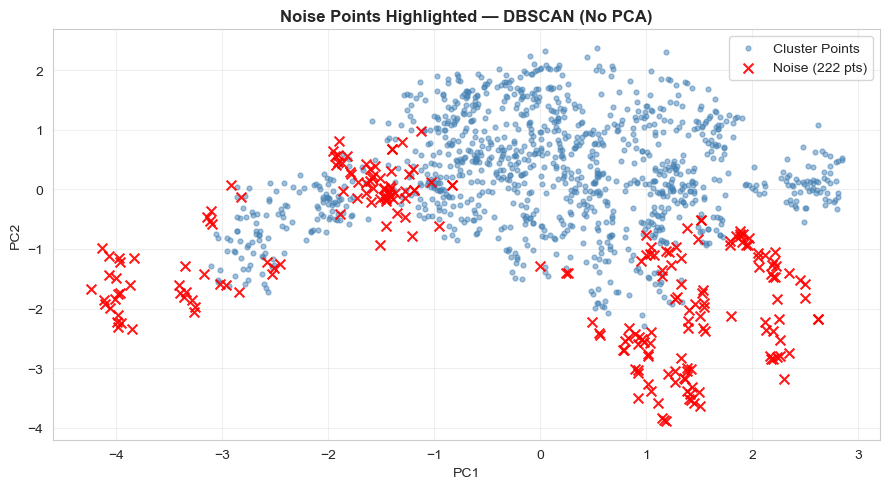

In [17]:
noise_mask = labels_full == -1
print(f'Total noise points (No PCA model): {noise_mask.sum()}')
print(f'True class of noise points:')
print(y[noise_mask].value_counts().rename({0:'Authentic', 1:'Forged'}).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(pca_coords[~noise_mask, 0], pca_coords[~noise_mask, 1],
           c='steelblue', s=12, alpha=0.5, label='Cluster Points')
ax.scatter(pca_coords[noise_mask, 0],  pca_coords[noise_mask, 1],
           c='red', s=50, alpha=0.9, marker='x',
           label=f'Noise ({noise_mask.sum()} pts)')
ax.set_title('Noise Points Highlighted — DBSCAN (No PCA)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Sensitivity Analysis

We sweep `eps` across a range to justify our chosen value and show how the number of clusters and noise points respond.

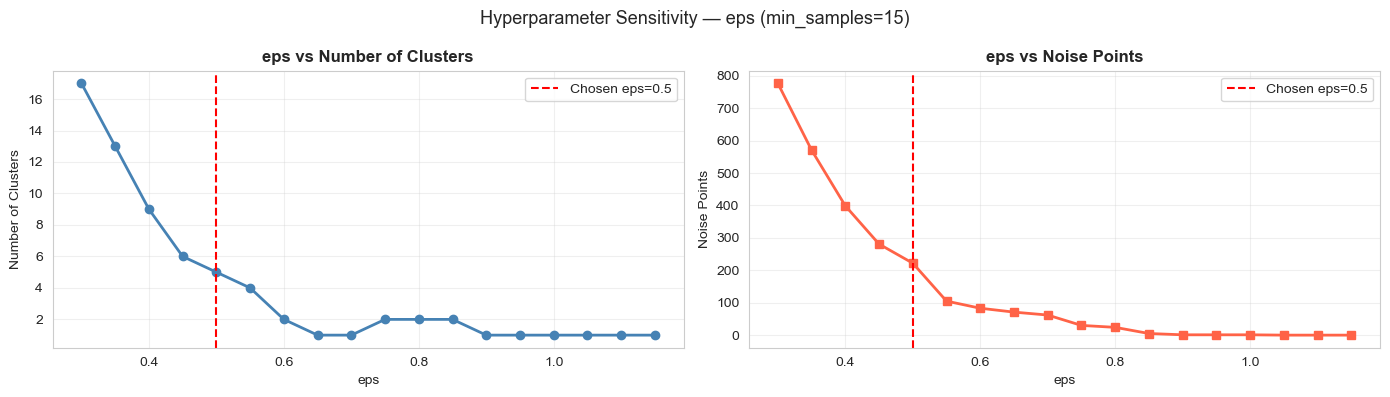

,eps,n_clusters,n_noise
0,0.30,17,777
1,0.35,13,571
2,0.40,9,399
3,0.45,6,281
4,0.50,5,222
5,0.55,4,105
6,0.60,2,83
7,0.65,1,71
8,0.70,1,62
9,0.75,2,30


In [19]:
eps_range = np.arange(0.3, 1.2, 0.05)
sens = []

for e in eps_range:
    lbl = DBSCAN(eps=round(e, 2), min_samples=MIN_SAMPLES).fit_predict(df_no_pca.values)
    n_cls   = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    sens.append({'eps': round(e, 2), 'n_clusters': n_cls, 'n_noise': n_noise})

sens_df = pd.DataFrame(sens)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sens_df['eps'], sens_df['n_clusters'], marker='o', color='steelblue', lw=2)
axes[0].axvline(EPS_FULL, color='red', ls='--', lw=1.5, label=f'Chosen eps={EPS_FULL}')
axes[0].set_xlabel('eps'); axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('eps vs Number of Clusters', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sens_df['eps'], sens_df['n_noise'], marker='s', color='tomato', lw=2)
axes[1].axvline(EPS_FULL, color='red', ls='--', lw=1.5, label=f'Chosen eps={EPS_FULL}')
axes[1].set_xlabel('eps'); axes[1].set_ylabel('Noise Points')
axes[1].set_title('eps vs Noise Points', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Hyperparameter Sensitivity — eps (min_samples={MIN_SAMPLES})', fontsize=13)
plt.tight_layout()
plt.savefig('sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

display(sens_df)

## 11. Summary & Interpretation

### Results (No PCA Model — Best Performer)

| Metric | Value | Interpretation |
|---|---|---|
| Clusters Found | 5 | DBSCAN found 5 density regions |
| Noise Points | 222 (16.5%) | Points too sparse to cluster |
| Silhouette Score | 0.196 | Moderate cluster separation |
| ARI | 0.549 | Reasonable alignment with true labels |
| Homogeneity | 0.811 | Clusters are quite pure (one class dominant) |
| Completeness | 0.420 | True classes spread across multiple clusters |
| V-Measure | 0.553 | Balanced metric: moderate overall |

### Key Findings
- The **No PCA model** significantly outperforms the PCA model — the 4-feature space preserves density structure better than the 2D reduction.
- **Homogeneity of 0.811** shows each DBSCAN cluster is dominated by a single true class — clusters are meaningful.
- Lower completeness (0.420) means each true class is split across multiple sub-clusters, reflecting the multi-modal density of banknote features.
- **Noise points (16.5%)** represent borderline/ambiguous banknotes — neither clearly authentic nor forged. These match the outliers flagged during preprocessing.
- The PCA model collapses into 1 large cluster because 2D reduction merges the density regions that DBSCAN can separate in 4D.

### Limitations
- DBSCAN assumes **equal-density clusters** — the banknote data has regions of varying density, leading to multiple sub-clusters per class.
- `eps` is sensitive: small changes shift clusters or noise dramatically (shown in sensitivity plot).
- Noise points are unclassified — in a real application, these would need manual review or a secondary classification step.